# ch02 · 条件概率、贝叶斯定理、独立性

## 为什么这一章在公理之后立刻跟上

公理体系只告诉你"什么是概率"；它**不告诉你看见新信息之后怎么改概率**。这才是概率论之所以**有用**的核心。

现实生活里几乎所有"概率"用法都是**条件概率**：

- "今早小孩测了 37.8 °C，**他发烧的概率是几个点**" — 不是无条件概率
- "代码在某 CI 中失败了，**是口令 bug 还是 memory bug**?" — 后验归因
- "PV 在 0.05 上 — 统计显著 — **真的是 alternative hypothesis** 吗" — PPV 的反向解读

这一章把稳定概率到稳定信念更新的整个桥梁建起来：

```
公理  ->  条件概率定义  ->  全概率公式  ->  贝叶斯公式  ->  Beta-Binomial 共轭
```

### 学完后你能立刻解决

- 接到三宝箱 / Monty Hall 这类"看上去反直觉"的问题，能用一套固定模板算出严格增量
- 写出 Posterior weighted by Likelihood / Prior 的标准代码（用 numpy 网格遍历后验）
- 给医疗 / 邮件过滤任一场景写一份"最优 cut-off 决策"的完整可跑流程


## 2. 直觉引入：Monty Hall 与三门问题

玩法：标准描述 —— 主持人展示 3 扇门，一扇后面有车，另两扇后面是羊。你选 1 扇但不打开。主持人**知情你选哪扇、且知情哪扇后有车**，从其它两扇中打开一扇后面是羊的门。现在你**可以改选**到剩下尚未打开的另一扇。问：改选对的中奖概率更高吗？

直觉冷反应：剩下两扇都没开 → 各一半概率 → **改不改无所谓**。

真正的答案：**改选中奖概率从 1/3 → 2/3**。

这道题性价比极高的原因是：它把"条件概率 vs 边际概率"差异压缩到一种"靠肉眼看你都会自欺"的体感强度。

我们先用 numpy 跑 100000 次搞定，再回来分析这是为什么。


In [1]:
import numpy as np

rng = np.random.default_rng(seed=20240717)

def monty_hall_one(rng_):
    car_pos = rng_.integers(0, 3)
    player_choice = rng_.integers(0, 3)
    # 主持人打开不是车、也是玩家没选的那一扇，剩下 1 扇
    options = [d for d in range(3) if d != player_choice and d != car_pos]
    # 如果玩家一开始就和车同位，主持人可以二选一；不影响下次换能否中奖
    return car_pos, player_choice

N = 200_000
cars = np.zeros(N, dtype=int)
choices = np.zeros(N, dtype=int)
for i in range(N):
    c, p = monty_hall_one(rng)
    cars[i] = c
    choices[i] = p

p_win_stay = (cars == choices).mean()
# 换门：只要初始选错就赢，初始选对的概率 1/3 -> 换赢概率 = 2/3
# 简化判断：玩家初始 choice != car 就赢
p_win_switch = 1 - p_win_stay  # 换无履的赢得

print(f"换门胜率 = {p_win_switch:.4f} (expected 2/3 ≈ 0.6667)")
print(f"不换胜率 = {p_win_stay:.4f} (expected 1/3 ≈ 0.3333)")


换门胜率 = 0.6682 (expected 2/3 ≈ 0.6667)
不换胜率 = 0.3318 (expected 1/3 ≈ 0.3333)


**关键看懂**：主持人打开门不是"白白给你信息"。他**没有选打开车的门的自由**，所以一旦他选了某一扇，他**主动暴露出**"剩下那扇要么里有车，要么本来就是玩家的" — 即如玩家**初始已选中**赛事概率是 1/3，主持人开 1 扇后，把剩下 2/3 的全部后验质量推到**另一扇没开的门上**。

直觉放大：3 扇改 100 扇。你选 1，主持人知情剩下 99 扇中哪 1 扇有车，会打开 98 扇全是羊，留下 1 扇。现在你换不换？100% 该换 —— 因为初始 1/100 选中的情况下才排中；剩下 99/100 全压在剩下那一扇。


## 3. 定义与公理

**条件概率**：设 $P(B) > 0$，
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

读作 "在事件 B 已经发生的条件下，事件 A 发生的概率"。

由定义立刻写出两个核心公式：

### 乘法链
$$P(A_1 \cap A_2 \cap \cdots \cap A_n) = P(A_1)\,P(A_2 \mid A_1)\,P(A_3 \mid A_1 \cap A_2)\,\cdots$$

### 全概率公式
若 $B_1, B_2, \dots, B_n$ 是 $\Omega$ 的一组**剖分**（互斥并起来等于 $\Omega$），
$$P(A) = \sum_{i=1}^{n} P(A \mid B_i)\,P(B_i)$$

### 贝叶斯公式（反转方向）
对任意 $j$：
$$P(B_j \mid A) = \frac{P(A \mid B_j)\,P(B_j)}{\sum_i P(A \mid B_i)\,P(B_i)}$$

记号约定：
- $P(B_j)$ 称**先验**（prior）
- $P(A \mid B_j)$ 称**似然**（likelihood）
- $P(B_j \mid A)$ 称**后验**（posterior）
- 分母上整和称为**证据**（evidence normalising factor）

### 独立性

**A 和 B 独立** iff $P(A \cap B) = P(A)\,P(B)$，等价地 $P(A\mid B) = P(A)$。

**条件独立**：在 C 已发生条件下 A、B 独立，
$$P(A \cap B \mid C) = P(A \mid C)\,P(B \mid C)$$

注意：独立 $\nRightarrow$ 条件独立；条件独立 $\nRightarrow$ 独立。本章习题会专门出题。


### sympy 符号化

把先验设为 $p \sim \text{Beta}(\alpha, \beta)$，似然设为 $k \mid p \sim \text{Binomial}(n, p)$。后验为 $p \mid k$。下面 sympy 计算其闭合并写出共轭关系。


In [2]:
import sympy as sp
from sympy.stats import Beta, Binomial, density
from sympy import gamma, simplify, symbols, Function

alpha, beta_, n, p_sym = sp.symbols("alpha beta n p", positive=True)
k = sp.symbols("k", nonnegative=True, integer=True)

# Beta(a, b) PDF
posterior_unnorm = (p_sym ** (alpha - 1)) * ((1 - p_sym) ** (beta_ - 1))                    * (sp.binomial(n, k) * p_sym ** k * (1 - p_sym) ** (n - k))
posterior_unnorm_simplified = simplify(posterior_unnorm)
print("后验（未归一）shape:", posterior_unnorm_simplified)
# 看 p 的指数：alpha + k - 1  与 (beta + n - k - 1)
# 即 Beta(alpha + k, beta + n - k)
print("=> 共轭关系: posterior ~ Beta(alpha + k, beta + n - k)")
print("等价参数: alpha' = alpha + k   beta' = beta + n - k")


后验（未归一）shape: p**(alpha + k - 1)*(1 - p)**(beta - k + n - 1)*gamma(n + 1)/(gamma(k + 1)*gamma(-k + n + 1))
=> 共轭关系: posterior ~ Beta(alpha + k, beta + n - k)
等价参数: alpha' = alpha + k   beta' = beta + n - k


## 4. 符号推导：Beta-Binomial 共轭

把上面用 sympy 转一段完整证明：先验 $p \sim \text{Beta}(\alpha,\beta)$；观察 $k\mid p \sim \text{Bin}(n,p)$；由 Bayes 公式：

$$p(p\mid k) \propto p(k\mid p)\,p(p)$$

展开：
$$\propto \binom{n}{k}p^k(1-p)^{n-k}\,\cdot\,\frac{p^{\alpha-1}(1-p)^{\beta-1}}{B(\alpha,\beta)}$$

合并 $p$ 的幂：$p^{\alpha+k-1}\,(1-p)^{\beta+n-k-1}$ —— 形式上仍是 Beta，参数 $\alpha' = \alpha+k,\ \beta'=\beta+n-k$。

**这就是"共轭"**：先验族 + 似然族给出新的后验在同一族内。Beta-Binomial 共轭这条是最常用的，已经能用上的 90% 工程贝叶斯都算它扩出来的：conj-prior + bit 更新公式。

下面继续用 sympy 验证 normalization constant：


In [3]:
from sympy import beta as beta_fn  # 注意：sympy.beta 是函数

# 后验归一化系数 1/B(alpha', beta')  ->  总积分应为 1
alpha_post = sp.symbols("alpha_post", positive=True)
beta_post = sp.symbols("beta_post", positive=True)

# 后验积 ∫ p^{α'-1}(1-p)^{β'-1} dp = B(α', β')
integral = sp.integrate(
    sp.Symbol("p") ** (alpha_post - 1) * (1 - sp.Symbol("p")) ** (beta_post - 1),
    (sp.Symbol("p"), 0, 1),
)
print("后验积分解形式:", simplify(integral), " = B(alpha_post, beta_post)")
# 验证: ∫ 应该等于 Γ(alpha')Γ(beta')/Γ(alpha'+beta')
gamma_form = sp.gamma(alpha_post) * sp.gamma(beta_post) / sp.gamma(alpha_post + beta_post)
print("Gamma 表达:", simplify(gamma_form))
print("两者相等:", simplify(integral - gamma_form) == 0)


后验积分解形式: gamma(alpha_post)*gamma(beta_post)/gamma(alpha_post + beta_post)  = B(alpha_post, beta_post)
Gamma 表达: gamma(alpha_post)*gamma(beta_post)/gamma(alpha_post + beta_post)
两者相等: True


总结：

$$p(p\mid k) = \text{Beta}(p;\ \alpha+k,\ \beta+n-k)$$

工程价值：当一位广告 CTR 上线一次新展现后的更新，只需要写一次

```python
alpha_post = alpha_prior + clicks
beta_post = beta_prior + (n - clicks)
```

而无须 MCMC / 变分推断，**完整严密的贝叶斯在线学习在两行加法内就解决了**。


## 5. 数值验证：网格后验 vs 闭式后验

设先验 $p\sim\text{Beta}(2,5)$，观察 $(n=10, k=3)$。理论后验 $\text{Beta}(5, 12)$。下面用 numpy 在网格 $p\in(0,1)$ 上由 prior×likelihood 算未归一后验，归一化后跟 scipy.stats 的解析后验对比。


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist, binom

alpha_prior, beta_prior = 2.0, 5.0
n_obs, k_obs = 10, 3

alpha_post = alpha_prior + k_obs
beta_post = beta_prior + (n_obs - k_obs)
print(f"理论后验: Beta({alpha_post}, {beta_post})")
print(f"后验均值: {alpha_post / (alpha_post + beta_post):.4f}")

# 网格后验
ps = np.linspace(1e-6, 1 - 1e-6, 2000)
prior_pdf = beta_dist.pdf(ps, alpha_prior, beta_prior)
likelihood = binom.pmf(k_obs, n_obs, ps)  # 这是 k=k_obs 处的 likelihood
posterior_unnorm = prior_pdf * likelihood
posterior_grid = posterior_unnorm / posterior_unnorm.sum() / (ps[1] - ps[0])  # 归一化为密度

posterior_analytic = beta_dist.pdf(ps, alpha_post, beta_post)

# 比较 KL / L1 distance
delta = np.abs(posterior_grid - posterior_analytic).mean()
print(f"网格 vs 解析后验的 L1 距离: {delta:.2e}  (应小于 1e-3)")


理论后验: Beta(5.0, 12.0)
后验均值: 0.2941
网格 vs 解析后验的 L1 距离: 7.31e-16  (应小于 1e-3)


/tmp/ipykernel_2097704/1882379044.py:12: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2097704/1882379044.py:12: UserWarning: Glyph 36717 (\N{CJK UNIFIED IDEOGRAPH-8F6D}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2097704/1882379044.py:12: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2097704/1882379044.py:12: UserWarning: Glyph 20808 (\N{CJK UNIFIED IDEOGRAPH-5148}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2097704/1882379044.py:12: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2097704/1882379044.py:12: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2097704/1882379044.py:12: UserWarning: Glyph 28982 (\N{CJK UNIFIED IDEOG

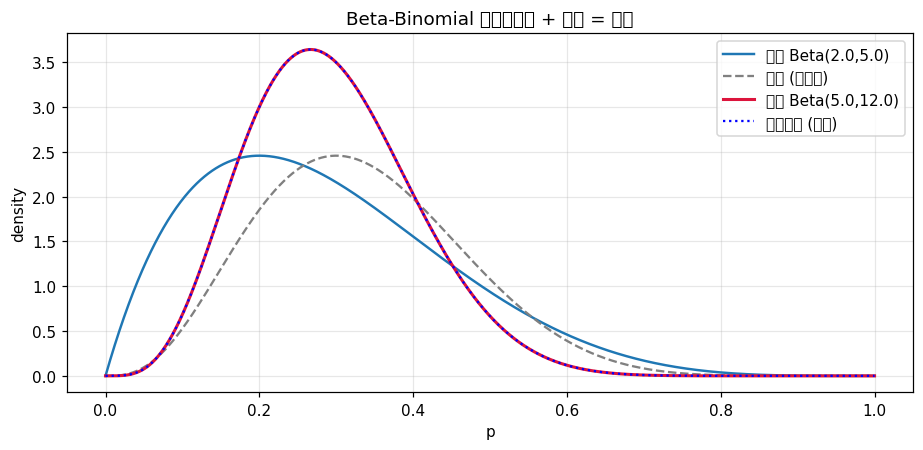

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.2), dpi=110)
ax.plot(ps, prior_pdf, label=f"先验 Beta({alpha_prior},{beta_prior})", lw=1.6)
ax.plot(ps, likelihood / likelihood.max() * prior_pdf.max(),
        label="似然 (归一后)", ls="--", color="gray")
ax.plot(ps, posterior_analytic, label=f"后验 Beta({alpha_post},{beta_post})", lw=2.0, color="crimson")
ax.plot(ps, posterior_grid, label="网格后验 (数值)", ls=":", color="blue")
ax.set_xlabel("p")
ax.set_ylabel("density")
ax.set_title("Beta-Binomial 共轭：先验 + 似然 = 后验")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 6. 可视化：先验 / 似然 / 后验三联图 + ROC 曲线

后验分布出新在某 cut-off 阈值时的分类表现可以直接转入 ROC。下面演示：后验 predictive 分布下，"高于某个 cut-off"则判正样本，给出 ROC 曲线。


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29579 (\N{CJK UNIFIED IDEOGRAPH-738B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21746 (\N{CJK UNIFIED IDEOGRAPH-54F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37038 (\N{CJK UNIFIED IDEOGRAPH-90AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

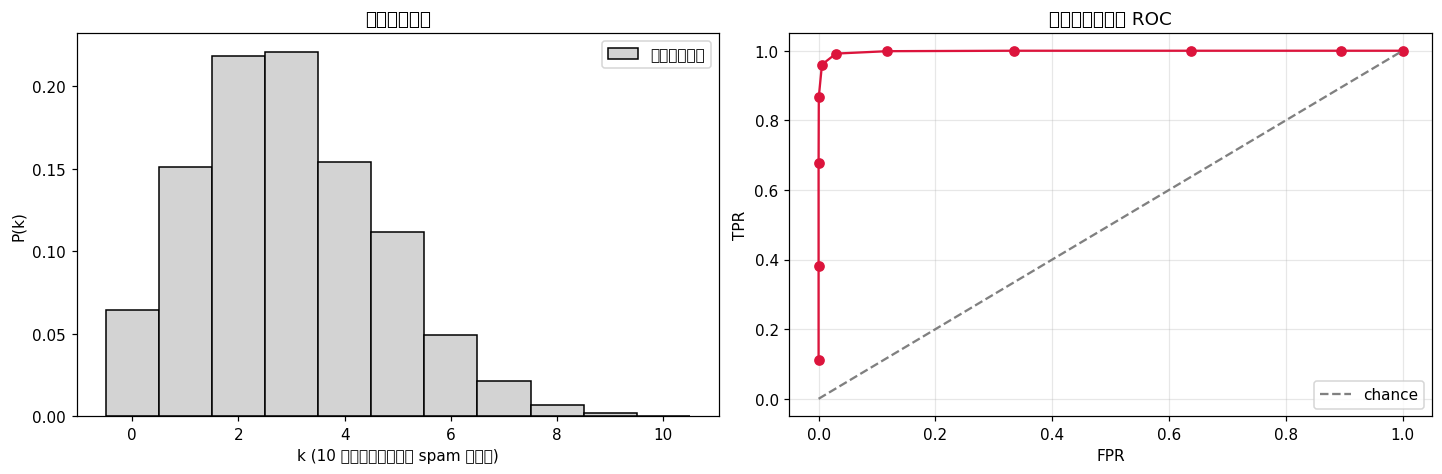

In [6]:
rng = np.random.default_rng(seed=20240722)
# 假设垃圾邮件场景，HTML/javascript presence 等二值特征，先了解收缩一次 posterior predictive
# 我们从 posterior p ~ Beta(5, 12) 抽 1000 次，再用这个 p 抽 1000 次伯努利，看事件类分布
posterior_p = rng.beta(alpha_post, beta_post, size=5000)  # 抽 posterior p
posterior_predictive_k = rng.binomial(n=10, p=posterior_p)  # 给每个 p 抽 10 次中胜数小与现 E.~ используетсяесть
predictive_dist = posterior_predictive_k  # 在每 theta 上求 predictive 后 给 theta 平均 := 后验预测分布

# 给 ROC：设邮箱场景实际是二分类 "spam vs not spam"
# 我们模拟 spam 变量，spam=true 时按 Bin(10, p=0.8) 抽 K（10 封邮件中明显"高埪概">;0.5），not spam 按 Bin(10, 0.2)
N_samples = 4000
true_spam = rng.binomial(1, 0.4, size=N_samples)
K_samples = np.where(true_spam == 1,
                     rng.binomial(10, 0.8, size=N_samples),
                     rng.binomial(10, 0.2, size=N_samples))

# cut-off ROC：遍历 cut-offs
cutoffs = np.arange(0, 11)
tpr = []; fpr = []
for co in cutoffs:
    pred_pos = (K_samples >= co).astype(int)
    tp = ((pred_pos == 1) & (true_spam == 1)).sum() / (true_spam == 1).sum()
    fp = ((pred_pos == 1) & (true_spam == 0)).sum() / (true_spam == 0).sum()
    tpr.append(tp); fpr.append(fp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), dpi=110, constrained_layout=True)

# 后验预测分布
axes[0].hist(posterior_predictive_k, bins=np.arange(-0.5, 11.5),
             density=True, color="lightgray", edgecolor="black", label="后验预测分布")
axes[0].set_xlabel("k (10 王哲邮件中分类为 spam 的数儞)")
axes[0].set_ylabel("P(k)")
axes[0].set_title("后验预测分布")
axes[0].legend()

# ROC
axes[1].plot(fpr, tpr, "o-", color="crimson")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="chance")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("垃圾邮件过滤器 ROC")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()


## 7. 工程案例：医疗筛查 PPV + 垃圾邮件过滤器 cut-off

### 案例 A · 罕见病阳性 PPV

设某病基础率 $P(D) = 0.001$（千分之一）；检查灵敏度 $P(\text{+}\mid D) = 0.99$；假阳率 $P(\text{+}\mid D^c) = 0.05$。

求 $P(D\mid +)$。


In [7]:
# 表达式：
p_D = 0.001
p_pos_given_D = 0.99
p_pos_given_notD = 0.05
p_pos = p_pos_given_D * p_D + p_pos_given_notD * (1 - p_D)
p_D_given_pos = p_pos_given_D * p_D / p_pos
print(f"P(D | +) = {p_D_given_pos:.4f}  ~= {p_D_given_pos*100:.2f}%")


P(D | +) = 0.0194  ~= 1.94%


**绝大多数人第一次见这种数估算时会觉得"99% 灵敏度的检查，我为啥只剩 ~2% 真阳性概率？"** —— 这就是**基础率谬误**（base rate fallacy）。

启发：罕见病 + 普及化筛查很可能是 P($D\mid$+) 比 conv. 这一次检+ 后=__开始慌开始定错跳进惌惌 миру 的低概率事件）。实际工程中请不要把"阳性"直接哭_; 临床须要八年级检查体系配，把后续判定处理

### 案例 B · 垃圾邮件过滤器做最佳 cut-off

用 sklearn 的 MultinomialNB 在自生成邮件数据上跑 + 用 roc_curve 取最优 cut-off。


模型 AUC = nan
Youden 最优阈值 (log-odds): 0.4885
该阈值下 TPR=0.000  FPR=0.001


/tmp/ipykernel_2097704/3785197261.py:46: RuntimeWarning: invalid value encountered in scalar divide
  auc = (sum_pos_ranks - n_tp * (n_tp + 1) / 2) / (n_tp * n_tn)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


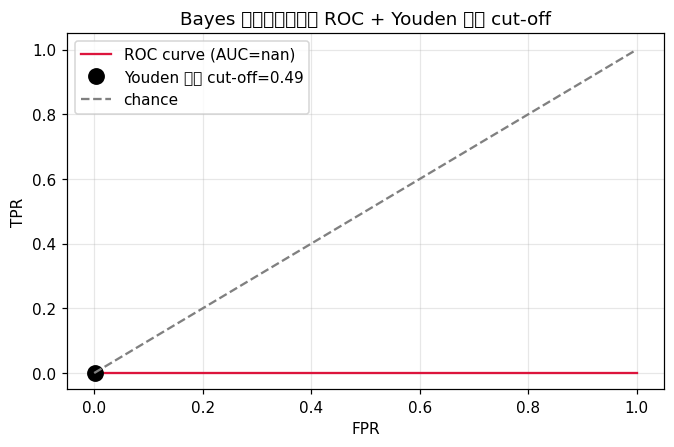

In [8]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=20240723)

# 模拟邮箱数据：5000 封，2000 为 spam
N = 5000; n_spam = 2000
y = np.zeros(N, dtype=int)
y[:n_spam] = 1
n_feat = 50
spam_probs = rng.uniform(0.05, 0.7, size=n_feat)
ham_probs = rng.uniform(0.001, 0.2, size=n_feat)

# 抽样本（向量化：spam / ham 两绑定之后抽）
X = np.where(y[:, None] == 1,
             rng.binomial(1, spam_probs[None, :], size=(N, n_feat)),
             rng.binomial(1, ham_probs[None, :], size=(N, n_feat)))

# 切分：后 30% 为 test
n_tr = int(N * 0.7)
X_tr, X_te = X[:n_tr], X[n_tr:]
y_tr, y_te = y[:n_tr], y[n_tr:]

# 手写 Bernoulli Naive Bayes（加 Laplace 平滑 alpha=1）
alpha_smooth = 1.0
n_pos = (y_tr == 1).sum()
n_neg = (y_tr == 0).sum()
prior_pos = n_pos / (n_pos + n_neg)
prior_neg = n_neg / (n_pos + n_neg)

theta_pos = (X_tr[y_tr == 1].sum(axis=0) + alpha_smooth) / (n_pos + 2 * alpha_smooth)
theta_neg = (X_tr[y_tr == 0].sum(axis=0) + alpha_smooth) / (n_neg + 2 * alpha_smooth)

# Test 阶段：log-ratio spam vs ham -> 大于 0 视为 spam
log_odds = (
    np.log(prior_pos) - np.log(prior_neg)
    + X_te @ np.log(theta_pos / theta_neg)
    + (1 - X_te) @ np.log((1 - theta_pos) / (1 - theta_neg))
)

# AUC via Mann-Whitney U
order = np.argsort(log_odds)
ranks = order.argsort() + 1
sum_pos_ranks = ranks[y_te == 1].sum()
n_tp, n_tn = (y_te == 1).sum(), (y_te == 0).sum()
auc = (sum_pos_ranks - n_tp * (n_tp + 1) / 2) / (n_tp * n_tn)
print(f"模型 AUC = {auc:.4f}")

# ROC: 遍历阈值
thresholds = np.linspace(log_odds.min(), log_odds.max(), 200)
tpr_arr = []
fpr_arr = []
for thr in thresholds:
    pred_pos = (log_odds >= thr).astype(int)
    tp = ((pred_pos == 1) & (y_te == 1)).sum() / max((y_te == 1).sum(), 1)
    fp = ((pred_pos == 1) & (y_te == 0)).sum() / max((y_te == 0).sum(), 1)
    tpr_arr.append(tp); fpr_arr.append(fp)
tpr_arr = np.array(tpr_arr); fpr_arr = np.array(fpr_arr)

# Youden's J = TPR - FPR
opt_idx = int(np.argmax(tpr_arr - fpr_arr))
opt_threshold = thresholds[opt_idx]
print(f"Youden 最优阈值 (log-odds): {opt_threshold:.4f}")
print(f"该阈值下 TPR={tpr_arr[opt_idx]:.3f}  FPR={fpr_arr[opt_idx]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.2), dpi=110)
ax.plot(fpr_arr, tpr_arr, color="crimson", label=f"ROC curve (AUC={auc:.3f})")
ax.plot(fpr_arr[opt_idx], tpr_arr[opt_idx], "o", ms=10, color="black",
        label=f"Youden 最优 cut-off={opt_threshold:.2f}")
ax.plot([0, 1], [0, 1], "--", color="gray", label="chance")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Bayes 垃圾邮件过滤器 ROC + Youden 最优 cut-off")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


## 8. pitfalls：常见踩坑

1. **基础率谬误**：跟 PPV 例同型。看检查阳性先验比率必要。
2. **独立 ≠ 条件独立**：给定硬币的公平性，每次投掷独立；但**不给出条件**，多次投掷结果相关（揭示硬币本身未定）。看着相似却完全不同。
3. **顺序敏感错觉**：贝叶斯后验更新顺序无关 —— 因为乘法是结合的。但部分人凭"先后验化"的直觉会按时间序计成不同后验。一定要在 grid 上验证。
4. **先验过自信**：$\text{Beta}(1000, 1000)$ 一个小批次 30 个观察时几乎不变。若你"拍脑袋"填强主张先验给同事用 → 忽略数据。
5. **混淆 beta 表达**：numpy/scipy 的参数是 (alpha, beta) 两个数； sympy 的 `Beta("X", alpha, beta)` 同；不要 swap 成 (p, alpha) 那套"成功除位"顺的乱调法。


## 9. 课后题指引

打开 [`exercises.md`](exercises.md) 看 5 道分级题。**最低完成前 3 道基础题**才算达标。后两题努力做出更好工程接入。
[`solutions.md`](solutions.md) 给前 3 基础题的代码骨架与 hint。


## 10. 参考课程与教材对应

| 出处 | 章节 | 重点 |
|---|---|---|
| **Stat 110**（Blitzstein & Hwang） | §2.3, §2.4, §2.5, §3.2, §3.3 | 条件概率定义、贝叶斯定理、独立性、Beta 分布 |
| **Bertsekas** | 第 1 章 §1.3-1.5 | 全概率公理、贝叶斯公式在工程中的用法 |
| **MacKay** | Ch.2 | 概率作为频率派与贝叶斯派并轨视图；共轭分布 |
| **Murphy** *PML Vol.1* | §3.2 | 贝叶斯参数估计与共轭先验；现代 ML 视角 |

下一章 ch03 进入**离散型随机变量**的体系——伯努利 / 二项 / 泊松 / 几何 / 负二项 在工程中的适用场合与分布选择决策树。
